# Multiple Sticker Model
Based off Indei & Takimoto (2010), we're gonna implement what they did and compare it to our model. The association and dissociation rates we will have to calculate ourselves from the simulations, so we can start with getting the same plots as they generate.

We make the same assumption that the association and dissociation rates of all the stickers is the same, $\alpha, \beta$.

Check out sticky_model.ipynb for the process of constructing this model. This notebook is just for matching it to our experimental data.

## Generating $\mathbf{K}(l)$

In [109]:
import numpy as np

def recursive_K(l, alpha, beta):
    if l == 1:
        return np.array([[1, beta],[alpha, 1]])
    else:
        tl = recursive_K(l-1, alpha, beta)
        tr = beta * np.identity(2 ** (l-1))
        bl = alpha * np.identity(2 ** (l-1))
        br = recursive_K(l-1, alpha, beta)
        return np.block([[tl, tr],
                          [bl, br]])

def recursive_K_list(l, alpha_list, beta_list):
    if l == 1:
        return np.array([[1, beta_list[0]],[alpha_list[0], 1]])
    else:
        tl = recursive_K_list(l-1, alpha_list[:-1], beta_list[:-1])
        tr = beta_list[l-1] * np.identity(2 ** (l-1))
        bl = alpha_list[l-1] * np.identity(2 ** (l-1))
        br = recursive_K_list(l-1, alpha_list[:-1], beta_list[:-1])
        return np.block([[tl, tr],
                          [bl, br]])


## Generating $\mathbf W(N_a)$

In [110]:
# N_a is the total number of stickers on a chain
def generate_W(N_a, alpha, beta):
    K_N_a = recursive_K(N_a, alpha, beta)
    K_upper = np.triu(K_N_a, 1)
    K_lower = np.tril(K_N_a, -1)
    
    W_diagonal = np.diagflat(-np.sum(K_N_a, axis=0)+1)

    return K_upper + K_lower + W_diagonal

def generate_W_lists(N_a, alpha_lit, beta_list):
    if len(alpha_lit) != len(beta_list) or len(alpha_lit) != N_a:
        raise ValueError("Incorrect number of association/dissociation parameters.")
    K_N_a = recursive_K_list(N_a, alpha_lit, beta_list)
    K_upper = np.triu(K_N_a, 1)
    K_lower = np.tril(K_N_a, -1)
    
    W_diagonal = np.diagflat(-np.sum(K_N_a, axis=0)+1)

    return K_upper + K_lower + W_diagonal


In [111]:
def extract_n_s(s, M, N_b):
    N_a = (N_b - 1) // M + 1
    if N_a < M:
        raise ValueError("N_a must be greater than or equal to M.")
    
    n_s = np.zeros(M * (N_a-1) + 1, dtype=int)

    index = 0
    while True:
        n_s[index] = s & 1
        s = s >> 1
        if s == 0:
            break
        if index >= M * (N_a-1):
            raise ValueError(f"s is too large to fit in the specified number of stickers and spacing, s^max = {2 ** N_a - 1}.")
        index += M
    return n_s


In [112]:
# Note: negating 0 gives -1, we have to add some int() typecasts
def generate_B(s, M, N_b):
    if (N_b-1) % M != 0:
        raise ValueError("N_b-1 must be divisible by M.")
    n_s = extract_n_s(s, M, N_b)
    B = np.zeros((N_b-1, N_b-1))

    for i, pair in enumerate(zip(n_s[:-1], n_s[1:])):
        if i != 0: # a_i
            B[i, i-1] = -1 * int(pair[0]==0)
        if i != N_b - 2: # c_i
            B[i, i+1] = -1 * int(pair[1]==0)
        # b_i
        B[i, i] = (int(pair[0]==0) or int(pair[1]==0)) + (int(pair[0]==0) and int(pair[1]==0))

    return B

# Solving equations for $h_{k,l}^s, g_{k,l}^s$
We need to solve for coefficients $h_{k,l}^s, g_{k,l}^s$ governed by equation 25a
$$
- \omega h_{k,l}^s + \frac{k_b}{\zeta} \sum_{j=1}^{N_b-1}(B_{k,j}^sg_{j,l}^s + B_{l,j}^sg_{k,j}^s) = \sum_{s^\prime=0}^{s_\text{max}}W_{s^\prime, s} g_{k,l}^{s^\prime}
$$
and 25b
$$
\omega g_{k,l}^s-\omega \delta_{k,l} + \frac{k_b}{\zeta}\sum_{j=1}^{N_b-1}(B_{k,j}^sh_{j,l}^s+B_{l,j}^sh_{k,j}^s)=\sum_{s^\prime=0}^{s_\text{max}}W_{s^\prime,s}h_{k,l}^{s^\prime}
$$

In [ ]:
from scipy.sparse import lil_matrix, csr_matrix, csc_matrix, coo_matrix
from scipy.sparse.linalg import LinearOperator
from time import time

"""
Linear operator form of A, does not need to store/manipulate the full matrix. Intended for use with iterative solvers like GMRES.

Uses the same indexing scheme as the full matrix, check out construct_Ab for more details.

Args:
    - x: vectorized g and h, stacked
    - omega: omega value to calculate shear dynamic moduli -- each omega value gives us one value of G' and G'' each
    - B: (s_max + 1) x (N_b - 1) x (N_b - 1) bead connectivity matrix
    - W: (s_max + 1) x (s_max + 1) association state transition matrix
    - k_b: spring constant along backbone beads
    - zeta: friction constant from Langevin equation (also dimensionless friction constant, they are interchangeable)
    - N_k: number of Kuhn steps in one chain, used if dimensionless (i.e. if k_b is none, replaces k_b)
    - N_b: number of beads in one chain
    - M: spacing of stickers
    - N_a: number of stickers in one chain (if None, is calculated)
    - s_max: maximum association state (if None, is calculated)

Returns:
    - Ax: result of applying linear operator A to vector x

"""
def A_operator(x, omega, B, W, k_b=None, zeta=1e-5, N_k=128, N_b=31, M=5, N_a=7, s_max=None):
    if N_a == None:
        N_a = (N_b - 1) // M + 1
    
    if s_max == None:
        s_max = 2**N_a - 1
    
    vectorize_length = (s_max + 1) * (N_b - 1) * (N_b - 1)

    if k_b == None:
        k_b_zeta = 3/(zeta * N_k)
    else:
        k_b_zeta = k_b/zeta


    Ax = np.zeros_like(x)

    # this is pass by reference btw
    g = x[:vectorize_length].reshape(s_max+1, N_b-1, N_b-1)
    h = x[vectorize_length:].reshape(s_max+1, N_b-1, N_b-1)

    Ax_g = Ax[:vectorize_length].reshape(s_max+1, N_b-1, N_b-1)
    Ax_h = Ax[vectorize_length:].reshape(s_max+1, N_b-1, N_b-1)

    Wg = np.tensordot(W.T, g, axes=(1,0))
    Wh = np.tensordot(W.T, h, axes=(1,0))

    Bg_left = B @ g
    Bg_right = g @ B.T

    Bh_left = B @ h
    Bh_right = h @ B.T

    Ax_g += -omega * h + k_b_zeta * Bg_left + k_b_zeta * Bg_right - Wg
    Ax_h += omega * g + k_b_zeta * Bh_left + k_b_zeta * Bh_right - Wh
    
    # for s in range(s_max+1):
    #     Bs = B[s]
    #     # Ws = W[:, s]
    #     gs = g[s]
    #     hs = h[s]

    #     Bg_left = Bs @ gs
    #     Bg_right = gs @ Bs.T

    #     Bh_left = Bs @ hs
    #     Bh_right = hs @ Bs.T

    #     Ax_g[s] = -omega * hs + k_b_zeta * Bg_left + k_b_zeta * Bg_right - Wg[s]
    #     Ax_h[s] = omega * gs + k_b_zeta * Bh_left + k_b_zeta * Bh_right - Wh[s]

    return Ax

In [115]:
"""
Construct coupling matrix A and constant RHS b such that we can solve an equation Ax = b to get values of g, h
In this form, x is stacked vectorized g and h. Each row of A encodes an equation.
A encodes equation 25a in the first vectorize_length rows, and 25b in the second vectorize_length rows.

We additionally need B^s_{k,l} and W_{s', s} matrices. W isn't a problem, but B needs to be composed into a 
tensor for each valid value of s.

Generating with COO sparse matrix is the fastest out of what I tested.

Args:
    - omega: omega value to calculate shear dynamic moduli -- each omega value gives us one value of G' and G'' each
    - B: (s_max + 1) x (N_b - 1) x (N_b - 1) bead connectivity matrix
    - W: (s_max + 1) x (s_max + 1) association state transition matrix
    - k_b: spring constant along backbone beads
    - zeta: friction constant from Langevin equation (also dimensionless friction constant, they are interchangeable)
    - N_k: number of Kuhn steps in one chain, used if dimensionless (i.e. if k_b is none, replaces k_b)
    - N_b: number of beads in one chain
    - M: spacing of stickers
    - N_a: number of stickers in one chain (if None, is calculated)
    - s_max: maximum association state (if None, is calculated)
    - pbar: optional tqdm progress bar to update during construction (single global bar)
Returns:
    - A: matrix A encoding equations 25a and 25b to be applied to vectorized g and h.
    - b: RHS constants from equations 25a and 25b
"""
def construct_Ab(omega, B, W, k_b=None, zeta=1e-5, N_k=128, N_b=15, M=2, N_a=8, s_max=None, pbar=None):
    start = time()

    if N_a == None:
        N_a = (N_b - 1) // M + 1
    
    if s_max == None:
        s_max = 2**N_a - 1
    
    vectorize_length = (s_max + 1) * (N_b - 1) * (N_b - 1)

    if k_b == None:
        k_b_zeta = 3/(zeta * N_k)
        print(f"Using dimensionless k_b = 1/N_k = {1/N_k}, zeta = {zeta}, so k_b/zeta = {k_b_zeta}")
    else:
        k_b_zeta = k_b/zeta
        print(f"Using k_b = {k_b}, zeta = {zeta}, so k_b/zeta = {k_b_zeta}")

    b = np.zeros((2 * vectorize_length, 1))

    for s in range(s_max + 1):
        for k in range (1, N_b):
            for l in range (1, N_b):
                # for 25b, b = \omega \delta_{k,l}
                if k == l:
                    b[(s_max+1)*(N_b-1)**2 + s*(N_b-1)**2 + (k-1)*(N_b-1) + (l-1), 0] += omega
    A = LinearOperator((2 * vectorize_length, 2 * vectorize_length), matvec=lambda x: A_operator(x, omega, B, W, k_b=k_b, zeta=zeta, N_k=N_k, N_b=N_b, M=M, N_a=N_a, s_max=s_max))
    # print(f"Constructed A and b in {time() - start:.2f} seconds.")
    
    return A, b




In [116]:
def B_tensor(M=2, N_b=15):
    N_a = (N_b - 1) // M + 1
    s_max = 2**N_a - 1
    B = np.zeros((s_max + 1, N_b-1, N_b-1))
    for s in range(2**N_a):
        B_mat = generate_B(s=s, M=M, N_b=N_b)
        B[s] = B_mat
    return B
# B_tensor()


In [117]:
def count_associated(s, M=2, N_b=15):
    return np.sum(extract_n_s(s, M, N_b))

# n_c is density of chains
def nu_s(s, alpha, beta, M, N_b, n_c=1):
    N_a = (N_b - 1) // M + 1
    N_s = count_associated(s, M, N_b)
    return alpha**N_s * beta**(N_a - N_s) / (alpha + beta)**N_a * n_c
    

def dynamic_shear_moduli(x, alpha, beta, s_max, M, N_b, k_B=1, T=1, n_c=1):
    length = len(x)//2

    g = np.reshape(x[:length], (s_max+1, N_b-1, N_b-1))
    h = np.reshape(x[length:], (s_max+1, N_b-1, N_b-1))

    G_p = 0
    G_pp = 0 
    for s in range(s_max+1):
        for k in range(N_b-1):
            G_p += k_B*T* nu_s(s, alpha, beta, M, N_b, n_c)*g[s, k, k]
            G_pp += k_B*T* nu_s(s, alpha, beta, M, N_b, n_c)*h[s, k, k]

    return G_p, G_pp


In [118]:
from tqdm.notebook import tqdm
from scipy.sparse.linalg import spsolve, gmres
from joblib import Parallel, delayed
from time import time
from threadpoolctl import threadpool_limits

def solve_omega(omega, thread_limit=2, alpha=1, beta=1, N_b=31, N_a=7, M=5, n_c=0.0274):
    s_max = 2**N_a - 1

    # generating matrices
    B = B_tensor(M=M, N_b=N_b)
    W = generate_W(N_a=N_a, alpha=alpha, beta=beta)

    with threadpool_limits(limits=thread_limit):
        start = time()
        A, b = construct_Ab(omega, B, W, k_b=1.72, zeta=25, N_b=N_b, M=M, N_a=N_a, s_max=s_max)
        # print("Matrix constructed.")

        x, info = gmres(A, b)
        print("Solved for x w/ GMRES")
        assert info == 0, f"GMRES did not converge, info = {info}"
        
        G_p, G_pp = dynamic_shear_moduli(x, alpha=alpha, beta=beta, s_max=s_max, M=M, N_b=N_b, k_B=1, T=1, n_c=n_c)
        print(f"Omega: {omega:.4f}, G_p: {G_p:.4f}, G_pp: {G_pp:.4f}, time taken: {time() - start:.2f} seconds")
        del A, b, x
        return omega, G_p, G_pp


In [119]:
def solve_spectrum(omegas, n_jobs=10, thread_limit=2, alpha=1, beta=1, N_b=31, N_a=7, M=5, n_c=0.0274):
    results = Parallel(n_jobs=n_jobs)(
        delayed(solve_omega)(thread_limit=thread_limit, omega=omega, alpha=alpha, beta=beta, N_b=N_b, N_a=N_a, M=M, n_c=n_c) for omega in omegas
    )
    
    results_sorted = sorted(results, key=lambda t: t[0])

    # unpack
    omegas, G_p_list, G_pp_list = zip(*results_sorted)

    # convert to numpy arrays, faster for plotting/processing
    omegas = np.array(omegas)
    G_p_list = np.array(G_p_list)
    G_pp_list = np.array(G_pp_list)

    return omegas, G_p_list, G_pp_list

In [120]:
# N_k = 128
# zeta_tilde = 1e-5
# N_b = 15

# t_rouse = N_k * zeta_tilde * N_b**2 / np.pi**2
# print("Rouse time:", t_rouse)

In [ ]:
import pandas as pd

A_alpha_beta_list = [(80, 0.98, 0.0683), (80, 0.179, 0.138), (110, 0.0461, 0.00142), (110, 0.00524, 0.0355)]
# A_alpha_beta_list = [(80, 0.98, 0.0683)]
for A, alpha, beta in A_alpha_beta_list:
    omegas = np.logspace(-4, 2, 20)
    omegas_scheduler = np.zeros(20)
    omegas_scheduler[:10] = omegas[:10]
    omegas_scheduler[10:] = omegas[:9:-1]
    # print(omegas_scheduler)
    G_p_list, G_pp_list = solve_spectrum(omegas_scheduler, n_jobs=10, thread_limit=2, alpha=alpha, beta=beta, N_b=31, N_a=7, M=5, n_c=0.0274)[1:]
    df = pd.DataFrame({
        'omega': omegas,
        'G_p': G_p_list,
        'G_pp': G_pp_list
    })
    print(f"Alpha: {alpha}, Beta: {beta}")
    print("G' values:", G_p_list)
    print("G'' values:", G_pp_list)

    df.to_csv(f'data/comparison/sticky_model/Gp_Gpp_output_A_{A}_alpha_{alpha}_beta_{beta}.csv', index=False)

[1.00000000e-04 2.06913808e-04 4.28133240e-04 8.85866790e-04
 1.83298071e-03 3.79269019e-03 7.84759970e-03 1.62377674e-02
 3.35981829e-02 6.95192796e-02 1.00000000e+02 4.83293024e+01
 2.33572147e+01 1.12883789e+01 5.45559478e+00 2.63665090e+00
 1.27427499e+00 6.15848211e-01 2.97635144e-01 1.43844989e-01]
Using k_b = 1.72, zeta = 25, so k_b/zeta = 0.0688
Using k_b = 1.72, zeta = 25, so k_b/zeta = 0.0688
Using k_b = 1.72, zeta = 25, so k_b/zeta = 0.0688
Using k_b = 1.72, zeta = 25, so k_b/zeta = 0.0688
Using k_b = 1.72, zeta = 25, so k_b/zeta = 0.0688
Using k_b = 1.72, zeta = 25, so k_b/zeta = 0.0688
Using k_b = 1.72, zeta = 25, so k_b/zeta = 0.0688
Using k_b = 1.72, zeta = 25, so k_b/zeta = 0.0688
Using k_b = 1.72, zeta = 25, so k_b/zeta = 0.0688
Using k_b = 1.72, zeta = 25, so k_b/zeta = 0.0688
Solved for x w/ GMRES
Omega: 0.0695, G_p: 0.2888, G_pp: 0.1925, time taken: 10.86 seconds
Using k_b = 1.72, zeta = 25, so k_b/zeta = 0.0688
Solved for x w/ GMRES
Omega: 100.0000, G_p: 0.8220, G_

In [ ]:
import pandas as pd

paper_sticky_model_G_p_alpha_1 = pd.read_csv("data/comparison/sticky_Gp_alpha_1.csv", names=["omega", "G'"])
paper_sticky_model_G_pp_alpha_1 = pd.read_csv("data/comparison/sticky_Gpp_alpha_1.csv", names=["omega", "G''"])
my_sticky_model_moduli_alpha_1 = pd.read_csv("data/comparison/my_sticky_model_alpha_1.csv")
print(paper_sticky_model_G_p_alpha_1.head())

      omega        G'
0  0.020515  0.001256
1  0.023709  0.001674
2  0.027042  0.002182
3  0.030844  0.002837
4  0.035180  0.003688


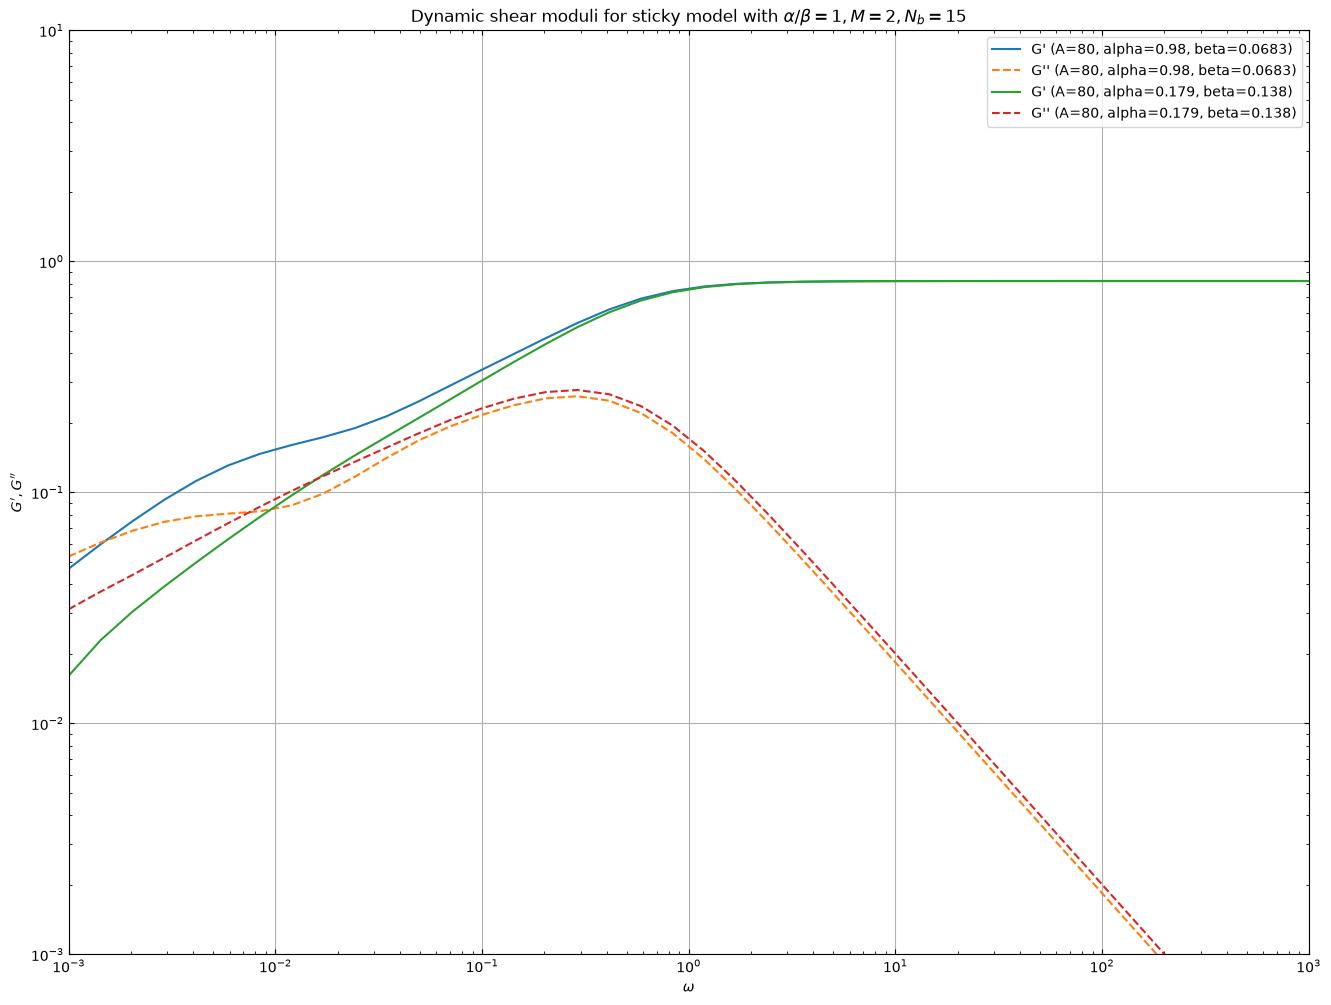

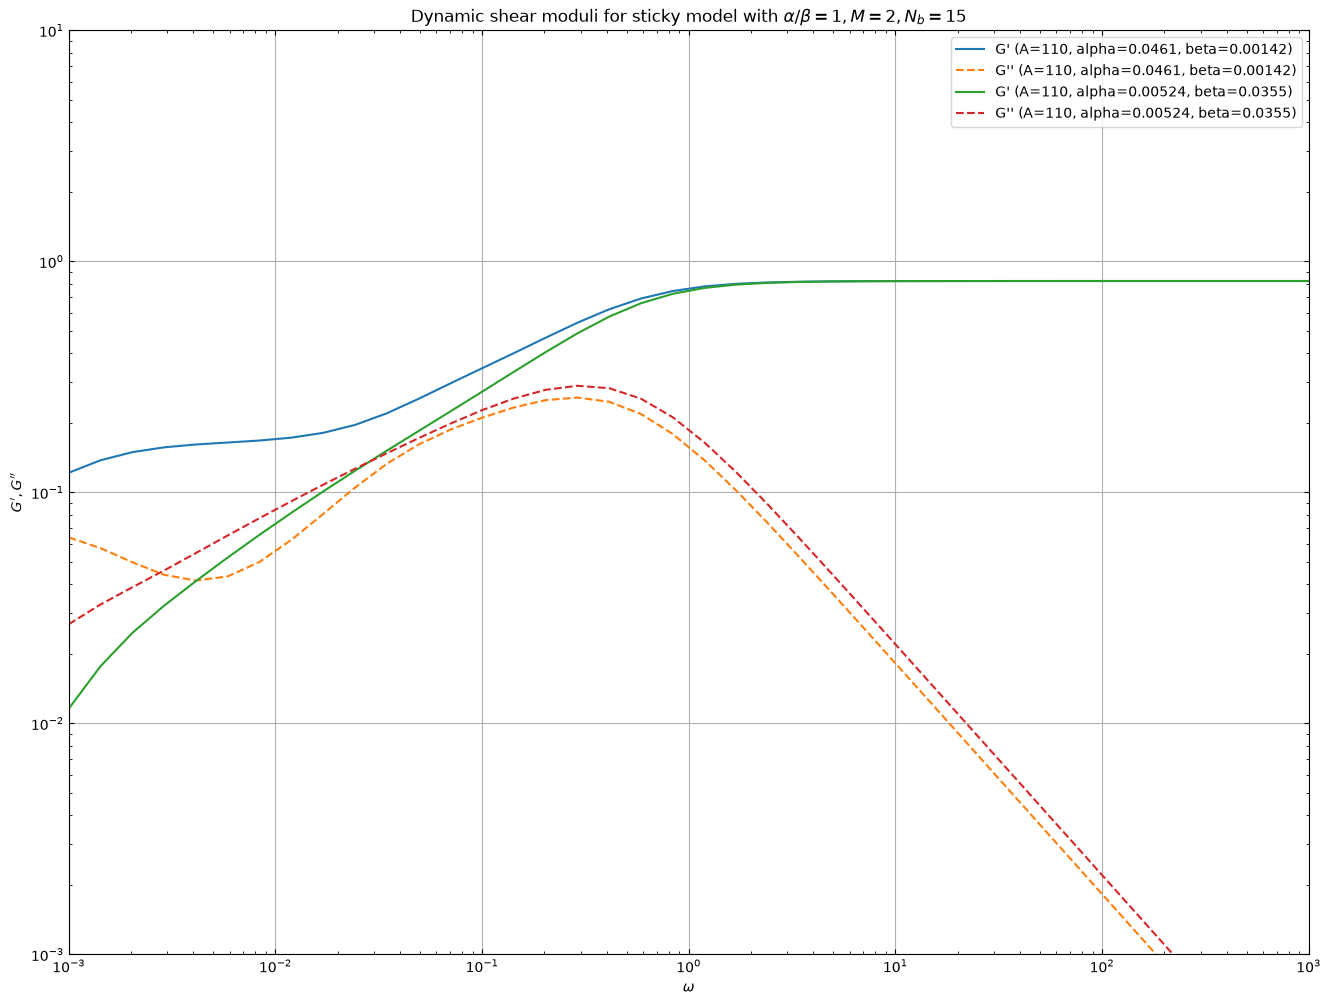

In [ ]:
import matplotlib.pyplot as plt

processed_As = set()
for A, alpha, beta in A_alpha_beta_list:
    if A in processed_As:
        continue
    processed_As.add(A)

for current_A in processed_As:
    figure = plt.figure(figsize=(16,12))
    for A, alpha, beta in A_alpha_beta_list:
        if A == current_A:
            df = pd.read_csv(f'data/comparison/sticky_model/Gp_Gpp_output_A_{A}_alpha_{alpha}_beta_{beta}.csv')
            plt.loglog(df['omega'], df['G_p'], label=f"G' (A={A}, alpha={alpha}, beta={beta})")
            plt.loglog(df['omega'], df['G_pp'], linestyle='--', label=f"G'' (A={A}, alpha={alpha}, beta={beta})")
    # plt.loglog(paper_sticky_model_G_p_alpha_1["omega"], paper_sticky_model_G_p_alpha_1["G'"], color='r', label="G'' (paper data)")
    # plt.loglog(paper_sticky_model_G_pp_alpha_1["omega"], paper_sticky_model_G_pp_alpha_1["G''"], color='r', linestyle='--', label="G'' (paper data)") 
    plt.title(r"Dynamic shear moduli for sticky model with $\alpha/\beta=1, M=2, N_b=15$")
    plt.xlabel(r"$\omega$")
    plt.ylabel(r"$G', G''$")
    plt.xlim(1e-4, 1e2)
    plt.ylim(1e-3, 1e1)
    plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    plt.legend()
    plt.grid()  
    plt.show()